In [1]:
using Markdown
using Printf
using Plots
using Statistics

In [2]:
function nested(d::Int, c::Vector{Float64}, x::Float64, xb::Vector{Float64} = zeros(d))
    if length(c) != d + 1
        error("Must have $(d+1) constants")
    end

    if length(xb) != d + 1
        error("Must have $(d+1) base points")
    end

    # string = "($(c[1]))"

    y = c[1]

    for i in 1:d
        y *= (x - xb[d - i + 1])
        y += c[i+1]
        # string = "($(c[i+1]) + (x - $(xb[d - i + 1]))" * string * ")"
    end


    return y
end

nested (generic function with 2 methods)

In [3]:
function newtonsInterpolation(x :: Vector{Float64}, y :: Vector{Float64}, divided_differences :: Vector{Vector{Float64}})
    start = length(divided_differences) == 0 ? 1 : length(divided_differences[1])

    if length(divided_differences) == 0
        push!(divided_differences, y)
    else
        divided_differences[1] = y
    end

    for i in start+1:length(x)
        push!(divided_differences, [])
    end

    curr_start = start;


    for i in 2:length(x)
        for j in curr_start:length(x) - i + 1
            divided_difference =  divided_differences[i-1][j + 1] - divided_differences[i - 1][j]
            push!(divided_differences[i], divided_difference/(x[j + i - 1] - x[j]))
        end

        if start != 1
            curr_start -= 1
        end
    end

    c = [divided_differences[length(divided_differences) - i + 1][1] for i in 1:length(divided_differences)]

    
    return divided_differences, (t::Float64) -> nested(length(x) - 1, c, t, x)
end

newtonsInterpolation (generic function with 1 method)

In [4]:
x = [1970.0, 1990.0, 1960.0, 2000]
y = [3707475887.0, 5281653820.0, 3039585530.0, 6079603571.0]
dd :: Vector{Vector{Float64}} = []

Any[]

In [5]:
dd, linear_interpolant = newtonsInterpolation(x[1:2], y[1:2], dd)
dd

2-element Vector{Vector{Float64}}:
 [3.707475887e9, 5.28165382e9]
 [7.870889665e7]

In [6]:
dd, quadratic_interpolant = newtonsInterpolation(x[1:3], y[1:3], dd)
dd

3-element Vector{Vector{Float64}}:
 [3.707475887e9, 5.28165382e9, 3.03958553e9]
 [7.870889665e7, 7.473560966666667e7]
 [397328.6983333334]

In [7]:
dd, cubic_interpolant = newtonsInterpolation(x[1:4], y[1:4], dd)
dd

4-element Vector{Vector{Float64}}:
 [3.707475887e9, 5.28165382e9, 3.03958553e9, 6.079603571e9]
 [7.870889665e7, 7.473560966666667e7, 7.6000451025e7]
 [397328.6983333334, 126484.13583333344]
 [-9028.152083333332]

In [8]:
linear_estimate = linear_interpolant(1980.0)
linear_estimate

4.4945648535e9

In [9]:
quadratic_estimate = quadratic_interpolant(1980.0)

4.454831983666667e9

In [10]:
cubic_estimate = cubic_interpolant(1980.0)

4.472888287833334e9

In [11]:
error_linear = 4452584592 - linear_estimate

-4.19802615e7

In [12]:
error_quadratic = 4452584592 - quadratic_estimate

-2.2473916666669846e6

In [13]:
error_cubic = 4452584592 - cubic_estimate

-2.030369583333397e7

In [14]:
Markdown.parse("""# Section 3.1: Computer Problem 1
    Linear Estimate for 1980 Population: ``p_1(1980)=`` $(linear_estimate)

    Linear Error for 1980 Population ``f(1980) - p_1(1980) = `` $(error_linear)

    Magnitude of Linear Error = ``|f(1980) - p_1(1980)| = `` $(abs(error_linear))
    
    Quadratic Estimate for 1980 Population: ``p_2(1980)=`` $(quadratic_estimate)

    Quadratic Error for 1980 Population ``f(1980) - p_2(1980) = `` $(error_quadratic)

    Magnitude of Quadratic Error for 1980 Population ``|f(1980) - p_2(1980)| = `` $(abs(error_quadratic))

    Cubic Estimate for 1980 Population: ``p_3(1980)=`` $(cubic_estimate)

    Cubic Error for 1980 Population ``f(1980) - p_3(1980) = `` $(error_cubic)

    Magnitude of Cubic Error for 1980 Population ``|f(1980) - p_3(1980)| = `` $(abs(error_cubic))

    """)

# Section 3.1: Computer Problem 1

Linear Estimate for 1980 Population: $p_1(1980)=$ 4.4945648535e9

Linear Error for 1980 Population $f(1980) - p_1(1980) =$ -4.19802615e7

Magnitude of Linear Error = $|f(1980) - p_1(1980)| =$ 4.19802615e7

Quadratic Estimate for 1980 Population: $p_2(1980)=$ 4.454831983666667e9

Quadratic Error for 1980 Population $f(1980) - p_2(1980) =$ -2.2473916666669846e6

Magnitude of Quadratic Error for 1980 Population $|f(1980) - p_2(1980)| =$ 2.2473916666669846e6

Cubic Estimate for 1980 Population: $p_3(1980)=$ 4.472888287833334e9

Cubic Error for 1980 Population $f(1980) - p_3(1980) =$ -2.030369583333397e7

Magnitude of Cubic Error for 1980 Population $|f(1980) - p_3(1980)| =$ 2.030369583333397e7


In [15]:
function cos1(x::Float64)
    xb = [0.0, pi/6, pi/3, pi/2]
    yb = [1.0, sqrt(3)/2, 1/2, 0.0]

    dd :: Vector{Vector{Float64}} = []
    dd, interpolant = newtonsInterpolation(xb, yb, dd)

    x = abs(x)

    x = x % 2pi
    sgn = 1
    
    if x > pi
        x = 2pi - x
    end

    if x > pi/2
        x = pi - x
        sgn = -1
    end

    return sgn * interpolant(x)
end

cos1 (generic function with 1 method)

# Section 3.1: Problem 4

The fundamental domain of cosine is [0, π/2].

So $\forall x \in [0, \pi/2]: \cos(x) = \cos(x)$.

Since cosine is symmetric about x axis: $\forall x \in (-\infty, 0]$ transform x by taking its absolute value so $x = |x|$

Since cosine is antisymmetric about $x = \pi/2$: $\forall x \in (\pi/2, \pi]$ $\cos(x) = -\cos(\pi - x)$. By doing $\pi - x$ we transform x to be between $[0, \pi/2]$ and we already know how to deal with this condition. We multiply by -1 to deal with the antisymmetry.

Finally cosine is symmetric about $x = \pi$: $\forall x \in (\pi, 2\pi]$, $\cos(x) = cos(2\pi - x)$. By doing $2\pi - x$ we transform our x to be between $[0, \pi]$ and we already know how to deal with x's in this condition.

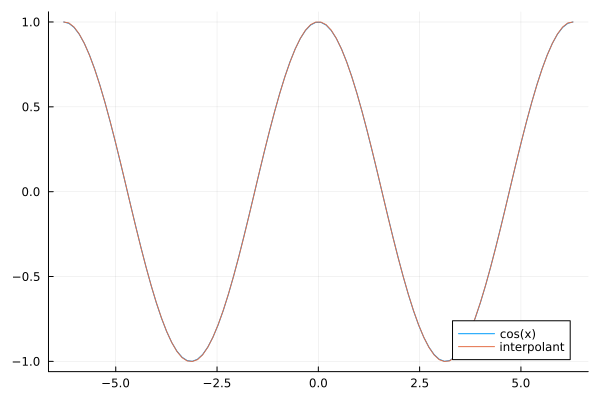

In [16]:
x = range(-2pi, 2pi, 100)
plot(x,[cos, cos1], label=["cos(x)" "interpolant"])

In [17]:
x = range(0, pi/2, 100)
y_actual =  cos.(x)
y_interpolate = cos1.(x)
rmse_error = sqrt(mean((y_actual - y_interpolate).^2))

Markdown.parse(""" # Root Mean squared Error
    Root Mean Squared Error for 100 equally spaced points between [0, pi/2]
    
    RMSE = $(rmse_error)
    """)

# Root Mean squared Error

Root Mean Squared Error for 100 equally spaced points between [0, pi/2]

RMSE = 0.001332481652253279
